# 08b — Long-Only Performance Attribution: Momentum Strategy (2019–2024)

Parallel analysis to NB08 for the **All6-EW + Momentum** strategy.
Allows direct comparison with TO\_MVO on all attribution metrics.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import rankdata

from src.data_loader import load_signal_data, FACTOR_COLUMNS, INDUSTRIES, COUNTRY_TC_BPS, DEFAULT_TC_BPS

OUTPUT_DIR = '../output'
HOLD_START = pd.Timestamp('2019-01-01')
REALISTIC_TC_BPS = 45.0

def ann_sharpe(s):
    s = s.dropna()
    if len(s) < 6 or s.std() == 0: return np.nan
    return s.mean()*12 / (s.std()*np.sqrt(12))
def ann_ret(s): return s.dropna().mean() * 12
def ann_vol(s): return s.dropna().std() * np.sqrt(12)
def max_dd(s):
    cum = (1 + s.dropna()).cumprod()
    return float((cum / cum.cummax() - 1).min())
# Momentum strategy data
hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv', index_col=0, parse_dates=True)
pc_ret = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_all_portfolio_returns.csv', index_col=0, parse_dates=True)
ind_ret = pd.read_csv(f'{OUTPUT_DIR}/csv/composite_all6_ew_industry_returns.csv', index_col=0, parse_dates=True)

COL_MOM = 'Momentum_All6EW_LW_60m'

eem_raw = pd.read_csv('../data/eem_returns_monthly.csv', index_col=0, parse_dates=True)
eem_raw['mret'] = pd.to_numeric(eem_raw['mret'], errors='coerce')
eem_raw = eem_raw.dropna(subset=['mret'])
eem_raw.index = eem_raw.index.to_period('M').to_timestamp()
eem_ret = eem_raw['mret'].sort_index()
eem_ret = eem_ret[~eem_ret.index.duplicated(keep='last')]

# Momentum turnover
stock_to = 0.1842
pc_to_mom = 0.0959
total_to_mom = stock_to + pc_to_mom  # 0.2801
TC_mom = total_to_mom * (REALISTIC_TC_BPS / 10_000)

strat = pc_ret[COL_MOM].dropna()
common = strat.index.intersection(eem_ret.index)
holdout = sorted([d for d in common if d >= HOLD_START])
s_h = strat.reindex(holdout)
eem_h = eem_ret.reindex(holdout)

print(f'Strategy: All6-EW + Momentum (holdout)')
print(f'Holdout: {len(holdout)} months ({holdout[0].strftime("%Y-%m")} to {holdout[-1].strftime("%Y-%m")})')
print(f'Turnover: {total_to_mom:.3f}/mo ({total_to_mom*12:.1f}x annual), TC drag: {TC_mom*12:.2%}/yr')

Strategy: All6-EW + Momentum (holdout)
Holdout: 69 months (2019-01 to 2024-09)
Turnover: 0.280/mo (3.4x annual), TC drag: 1.51%/yr


## 1. Standard Performance Measures

In [2]:
from src.residual_returns import estimate_rolling_beta

slope, intercept, r_value, p_value, std_err = stats.linregress(eem_h.values, s_h.values)
beta_full = slope
alpha_ann = intercept * 12
r_sq = r_value**2
residuals = s_h.values - (intercept + beta_full * eem_h.values)
s_p = np.std(residuals, ddof=1) * np.sqrt(12)
appraisal_ratio = alpha_ann / s_p if s_p > 0 else np.nan
treynor = (s_h.mean() * 12) / beta_full if beta_full != 0 else np.nan
sharpe = ann_sharpe(s_h)

s_h_net = s_h - TC_mom
slope_n, intercept_n, *_ = stats.linregress(eem_h.values, s_h_net.values)

print('='*70)
print('STANDARD PERFORMANCE MEASURES: All6-EW + Momentum (Holdout)')
print('='*70)
print(f'  Sharpe Ratio:       {sharpe:.3f} (net: {ann_sharpe(s_h_net):.3f})')
print(f'  Treynor Measure:    {treynor:.4f} ({treynor*100:.2f}%)')
print(f'  Jensen\'s Alpha:    {alpha_ann:.2%}/yr (net: {intercept_n*12:.2%})')
print(f'  Appraisal Ratio:    {appraisal_ratio:.3f}')
print(f'  Beta:               {beta_full:.3f}')
print(f'  R²:                 {r_sq:.3f}')
print(f'  Idiosyncratic Vol:  {s_p:.2%}')
print(f'\n  EEM Benchmark Sharpe: {ann_sharpe(eem_h):.3f}')

STANDARD PERFORMANCE MEASURES: All6-EW + Momentum (Holdout)
  Sharpe Ratio:       0.594 (net: 0.513)
  Treynor Measure:    0.1170 (11.70%)
  Jensen's Alpha:    4.86%/yr (net: 3.34%)
  Appraisal Ratio:    0.759
  Beta:               0.948
  R²:                 0.883
  Idiosyncratic Vol:  6.39%

  EEM Benchmark Sharpe: 0.356


## 2. Rolling Beta

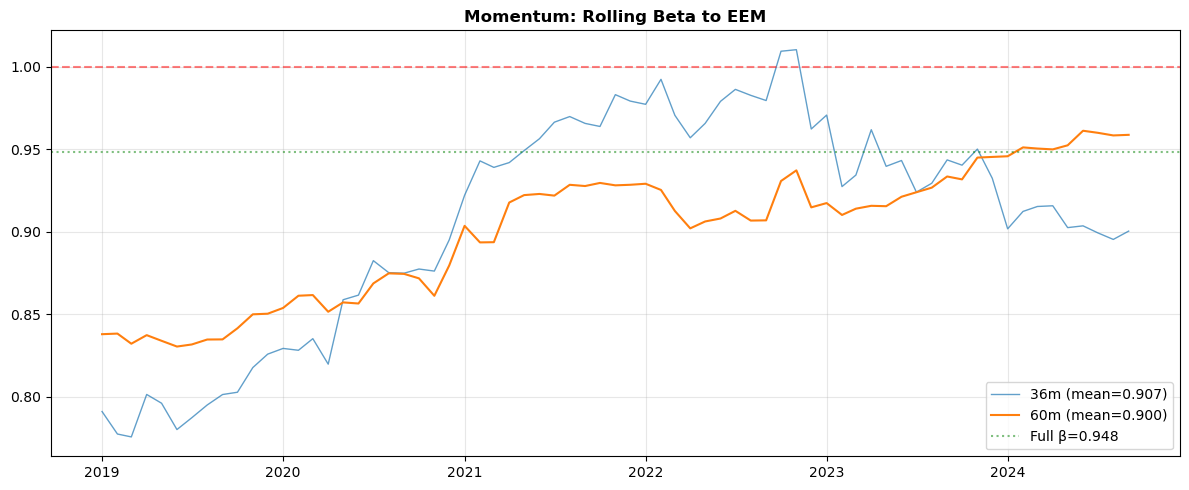

In [3]:
beta_36 = estimate_rolling_beta(strat, eem_ret, window=36, min_obs=18)
beta_60 = estimate_rolling_beta(strat, eem_ret, window=60, min_obs=24)
b36_h = beta_36[beta_36.index >= HOLD_START].dropna()
b60_h = beta_60[beta_60.index >= HOLD_START].dropna()

fig, ax = plt.subplots(figsize=(12, 5))
if len(b36_h) > 0: ax.plot(b36_h.index, b36_h, lw=1, alpha=0.7, label=f'36m (mean={b36_h.mean():.3f})')
if len(b60_h) > 0: ax.plot(b60_h.index, b60_h, lw=1.5, label=f'60m (mean={b60_h.mean():.3f})')
ax.axhline(y=1, color='red', ls='--', alpha=0.5); ax.axhline(y=beta_full, color='green', ls=':', alpha=0.5, label=f'Full β={beta_full:.3f}')
ax.set_title('Momentum: Rolling Beta to EEM', fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/figures/nb08b_rolling_beta.pdf', bbox_inches='tight'); plt.show()

## 3. Industry Exposure

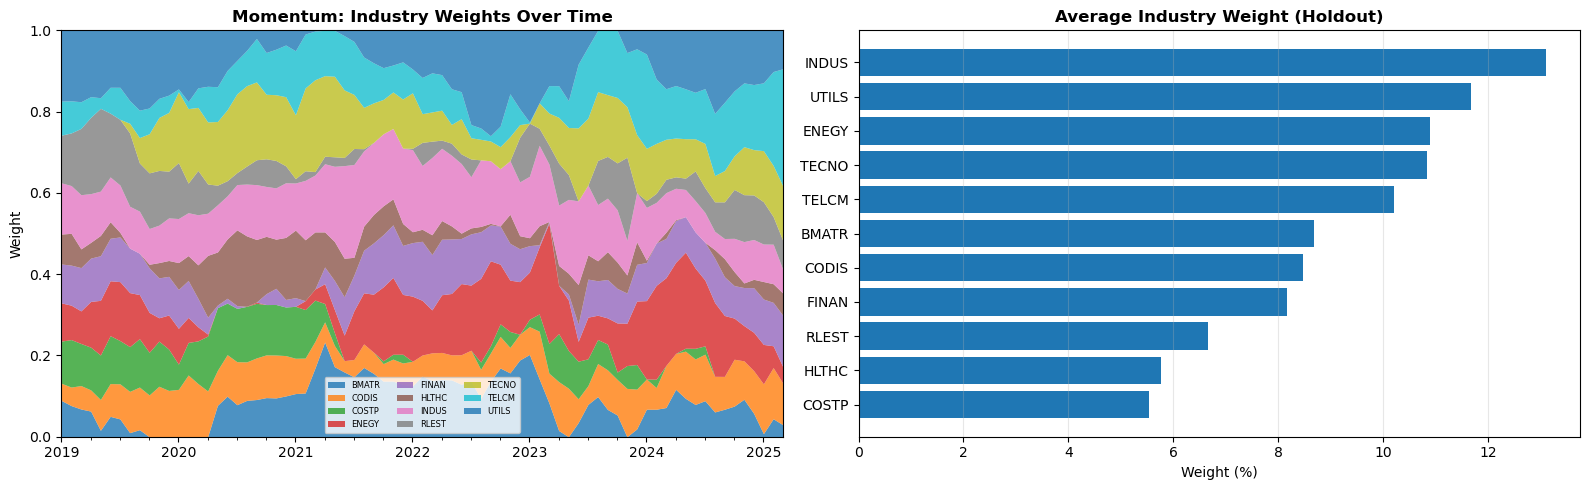

Momentum Weight Summary:
  Avg HHI: 0.1279 (EW=0.0909)
  Max weight: 29.6%
  Top 3: ENEGY, UTILS, INDUS


In [4]:
mom_weights = pd.read_csv(f'{OUTPUT_DIR}/csv/nb08_momentum_weights.csv', index_col=0, parse_dates=True)
mom_w_h = mom_weights[mom_weights.index >= HOLD_START]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
mom_w_h.plot.area(ax=ax, linewidth=0, alpha=0.8)
ax.set_title('Momentum: Industry Weights Over Time', fontweight='bold')
ax.set_ylabel('Weight'); ax.legend(fontsize=6, ncol=3); ax.set_ylim(0, 1)

ax = axes[1]
avg_w = mom_w_h.mean().sort_values(ascending=True)
ax.barh(avg_w.index, avg_w.values*100)
ax.set_title('Average Industry Weight (Holdout)', fontweight='bold')
ax.set_xlabel('Weight (%)'); ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/figures/nb08b_industry_exposure.pdf', bbox_inches='tight'); plt.show()

hhi = (mom_w_h**2).sum(axis=1)
print(f'Momentum Weight Summary:')
print(f'  Avg HHI: {hhi.mean():.4f} (EW={1/len(INDUSTRIES):.4f})')
print(f'  Max weight: {mom_w_h.max().max():.1%}')
print(f'  Top 3: {", ".join(avg_w.tail(3).index.tolist())}')

## 4. Monthly Alpha & Active Return

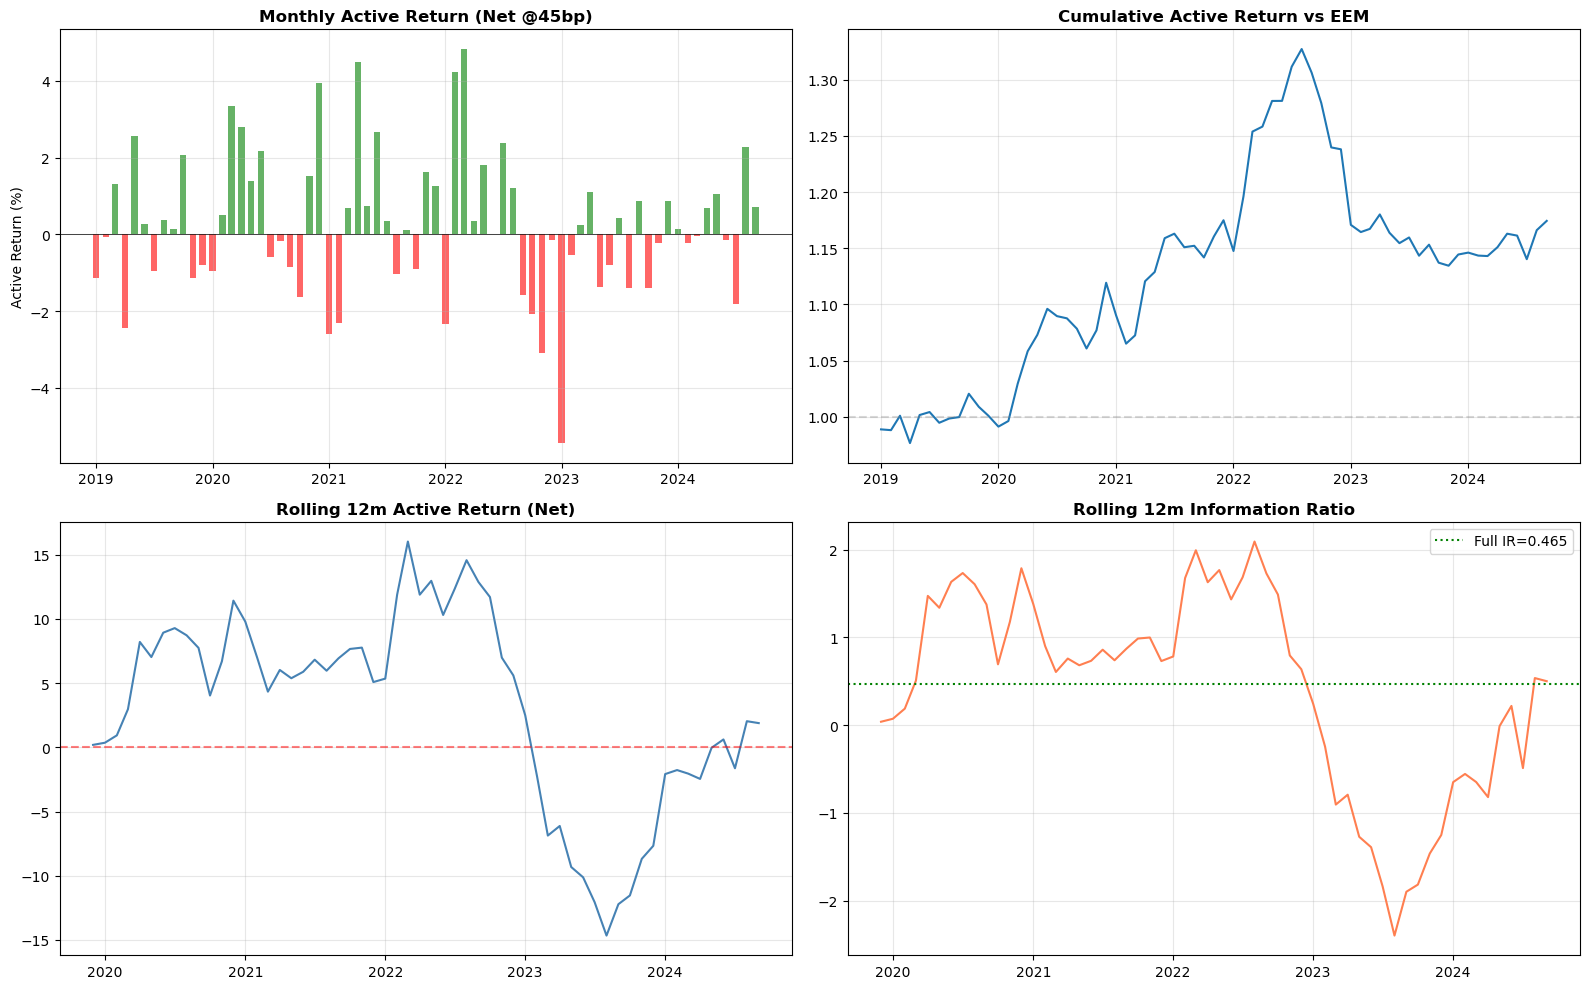

Active Return (Net @45bp): mean=3.00%/yr, TE=6.47%, IR=0.465
Hit rate: 55.1%


In [5]:
excess_net = s_h - TC_mom - eem_h

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax = axes[0, 0]
colors = ['green' if x > 0 else 'red' for x in excess_net.values]
ax.bar(excess_net.index, excess_net.values*100, color=colors, alpha=0.6, width=20)
ax.axhline(y=0, color='k', lw=0.5); ax.set_title('Monthly Active Return (Net @45bp)', fontweight='bold')
ax.set_ylabel('Active Return (%)'); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
cum_active = (1 + excess_net).cumprod()
ax.plot(cum_active.index, cum_active.values, lw=1.5)
ax.axhline(y=1, color='gray', ls='--', alpha=0.3)
ax.set_title('Cumulative Active Return vs EEM', fontweight='bold'); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
roll_alpha = excess_net.rolling(12).mean() * 12
ax.plot(roll_alpha.index, roll_alpha.values*100, lw=1.5, color='steelblue')
ax.axhline(y=0, color='red', ls='--', alpha=0.5)
ax.set_title('Rolling 12m Active Return (Net)', fontweight='bold'); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
te = excess_net.std() * np.sqrt(12)
ir = excess_net.mean() * 12 / te
roll_ir = excess_net.rolling(12).apply(lambda x: x.mean()*12/(x.std()*np.sqrt(12)) if x.std()>0 else 0)
ax.plot(roll_ir.index, roll_ir.values, lw=1.5, color='coral')
ax.axhline(y=ir, color='green', ls=':', label=f'Full IR={ir:.3f}')
ax.set_title('Rolling 12m Information Ratio', fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/figures/nb08b_alpha_analysis.pdf', bbox_inches='tight'); plt.show()

print(f'Active Return (Net @45bp): mean={excess_net.mean()*12:.2%}/yr, TE={te:.2%}, IR={ir:.3f}')
print(f'Hit rate: {(excess_net>0).mean():.1%}')

## 5. Annual Sub-Period

ANNUAL ACTIVE RETURN (Momentum, Net @45bp)
      Active Ret  Hit Rate  Sharpe    TE   N
Year                                        
2019       0.001     0.500   1.163 0.050  12
2020       0.118     0.583   1.147 0.064  12
2021       0.050     0.667   0.148 0.070  12
2022       0.054     0.583  -0.681 0.088  12
2023      -0.076     0.417   0.134 0.061  12
2024       0.026     0.556       2 0.038   9


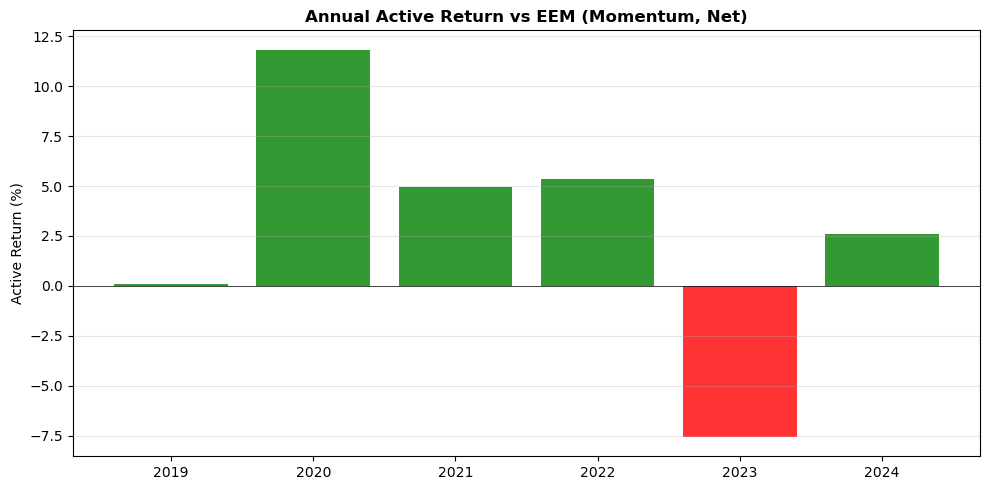

In [6]:
rows = []
for yr, g in excess_net.groupby(excess_net.index.year):
    rows.append({'Year': yr, 'Active Ret': (1+g).prod()-1, 'Hit Rate': (g>0).mean(),
                 'Sharpe': ann_sharpe(g + eem_h.reindex(g.index).fillna(0)),
                 'TE': g.std()*np.sqrt(12), 'N': int(len(g))})
annual = pd.DataFrame(rows).set_index('Year')
print('ANNUAL ACTIVE RETURN (Momentum, Net @45bp)')
print(annual.to_string(float_format=lambda x: f'{x:.3f}' if abs(x)<2 else f'{x:.0f}'))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if x>0 else 'red' for x in annual['Active Ret']]
ax.bar(annual.index.astype(int), annual['Active Ret']*100, color=colors, alpha=0.8)
ax.axhline(y=0, color='k', lw=0.5)
ax.set_title('Annual Active Return vs EEM (Momentum, Net)', fontweight='bold')
ax.set_ylabel('Active Return (%)'); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/figures/nb08b_annual_active.pdf', bbox_inches='tight'); plt.show()

## 6. Style Analysis

Style R²: 0.964 (96.4% explained)
Selection alpha: 0.03%/yr


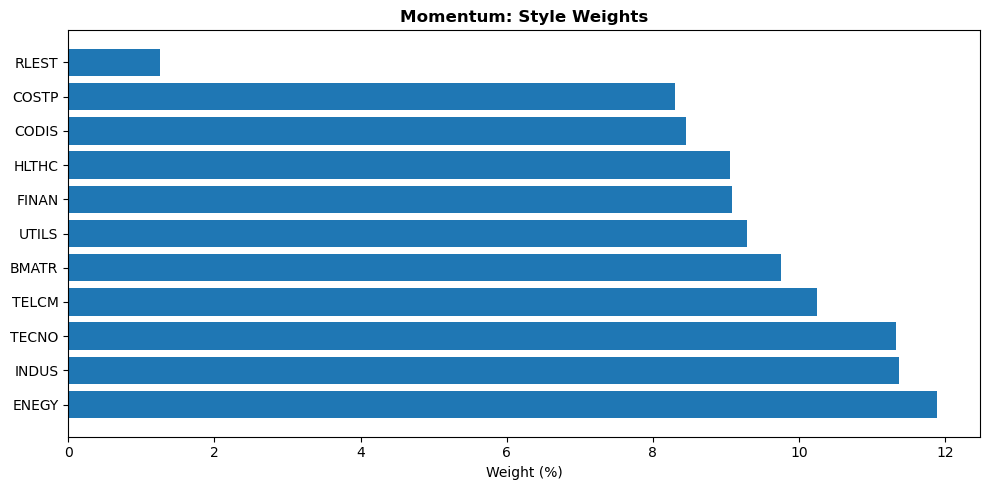

In [7]:
from scipy.optimize import minimize as sp_minimize

ind_h = ind_ret.reindex(holdout).dropna(how='all')
common_dates = s_h.index.intersection(ind_h.index)
X = ind_h.loc[common_dates].values
y = s_h.loc[common_dates].values

n_assets = X.shape[1]
result = sp_minimize(lambda w: np.var(y - X @ w), np.ones(n_assets)/n_assets,
                     method='SLSQP', bounds=[(0,1)]*n_assets,
                     constraints=[{'type':'eq','fun': lambda w: np.sum(w)-1}])
style_w = result.x
style_ret = X @ style_w
sel_ret = y - style_ret
r2_style = 1 - np.var(sel_ret) / np.var(y)

print(f'Style R²: {r2_style:.3f} ({r2_style*100:.1f}% explained)')
print(f'Selection alpha: {np.mean(sel_ret)*12:.2%}/yr')

fig, ax = plt.subplots(figsize=(10, 5))
nz = [(ind_h.columns[i], style_w[i]) for i in range(n_assets) if style_w[i] > 0.005]
nz.sort(key=lambda x: x[1], reverse=True)
ax.barh([x[0] for x in nz], [x[1]*100 for x in nz])
ax.set_title('Momentum: Style Weights', fontweight='bold'); ax.set_xlabel('Weight (%)')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/figures/nb08b_style_analysis.pdf', bbox_inches='tight'); plt.show()